Saved plot to: 1Hz.png


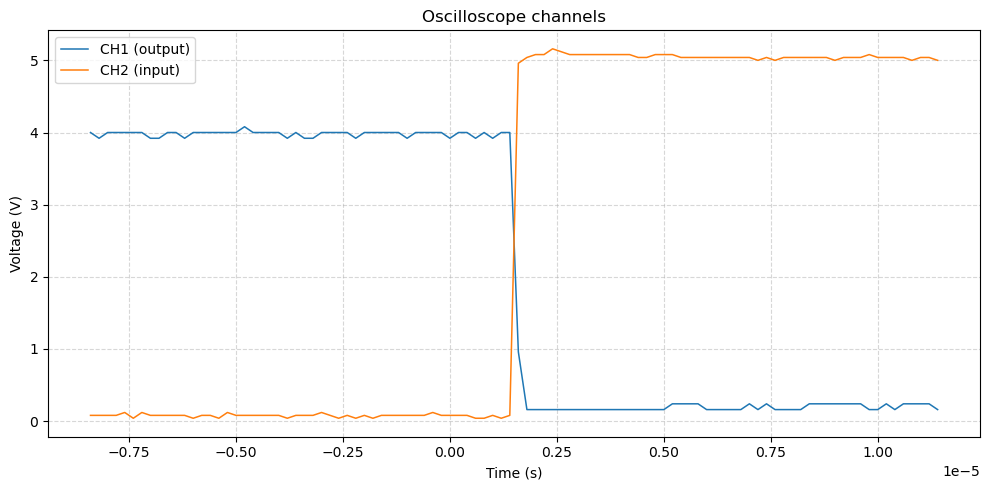

In [22]:
#!/usr/bin/env python3
"""
Plot oscilloscope data from CSV file.

This script:
 - Reads CSV data with format: <empty>,<empty>,<empty>,<time>,<ch1_volt>,<ch2_volt>
 - Plots CH1 and CH2 vs time, with labels, legend, grid, and saves a PNG.
"""

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def parse_csv_data(path: Path):
    """Return numpy arrays (t, ch1, ch2) from CSV file."""
    times = []
    ch1 = []
    ch2 = []
    
    with path.open('r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6:
                continue
            try:
                # Skip first 3 empty columns, read time, ch1, ch2
                t = float(parts[3])
                v1 = float(parts[4])
                v2 = float(parts[5])
                times.append(t)
                ch1.append(v1)
                ch2.append(v2)
            except (ValueError, IndexError):
                continue
    
    if len(times) == 0:
        raise ValueError(f"No numeric data rows found in file {path}")
    
    (a,b) = (8150, 8250)
    t = np.array(times, dtype=float)[a:b]
    v1 = np.array(ch1, dtype=float)[a:b]
    v2 = np.array(ch2, dtype=float)[a:b]
    return t, v1, v2


def plot_and_save(t, ch1, ch2, out_png: Path):
    plt.figure(figsize=(10, 5))
    plt.plot(t, ch1, label='CH1 (output)', linewidth=1.1)
    plt.plot(t, ch2, label='CH2 (input)', linewidth=1.1)
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.title('Oscilloscope channels')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    print(f"Saved plot to: {out_png}")
    plt.show()
    plt.close()


# Main execution
csv_path = Path('1Hz.CSV')
if not csv_path.exists():
    raise FileNotFoundError(f"File not found: {csv_path}")

t, v1, v2 = parse_csv_data(csv_path)

# Sort by time
order = np.argsort(t)
t = t[order]
v1 = v1[order]
v2 = v2[order]

out_path = csv_path.with_suffix('.png')
plot_and_save(t, v1, v2, out_path)


In [3]:
len(t)

16384

Saved plot to: 1Hz.png


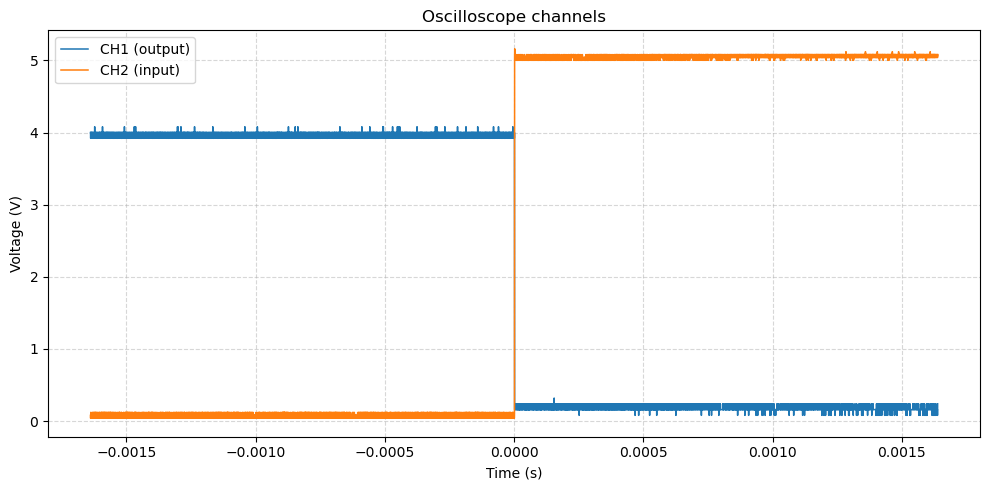

In [34]:
#!/usr/bin/env python3
"""
Plot oscilloscope data from CSV file.

This script:
 - Reads CSV data with format: <empty>,<empty>,<empty>,<time>,<ch1_volt>,<ch2_volt>
 - Plots CH1 and CH2 vs time, with labels, legend, grid, and saves a PNG.
"""

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def parse_csv_data(path: Path):
    """Return numpy arrays (t, ch1, ch2) from CSV file."""
    times = []
    ch1 = []
    ch2 = []
    
    with path.open('r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6:
                continue
            try:
                # Skip first 3 empty columns, read time, ch1, ch2
                t = float(parts[3])
                v1 = float(parts[4])
                v2 = float(parts[5])
                times.append(t)
                ch1.append(v1)
                ch2.append(v2)
            except (ValueError, IndexError):
                continue
    
    if len(times) == 0:
        raise ValueError(f"No numeric data rows found in file {path}")
    
    t = np.array(times, dtype=float)
    v1 = np.array(ch1, dtype=float)
    v2 = np.array(ch2, dtype=float)
    return t, v1, v2


def plot_and_save(t, ch1, ch2, out_png: Path):
    plt.figure(figsize=(10, 5))
    plt.plot(t, ch1, label='CH1 (output)', linewidth=1.1)
    plt.plot(t, ch2, label='CH2 (input)', linewidth=1.1)
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.title('Oscilloscope channels')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    print(f"Saved plot to: {out_png}")
    plt.show()
    plt.close()


# Main execution
csv_path = Path('1Hz.CSV')
if not csv_path.exists():
    raise FileNotFoundError(f"File not found: {csv_path}")

t, v1, v2 = parse_csv_data(csv_path)

# Sort by time
order = np.argsort(t)
t = t[order]
v1 = v1[order]
v2 = v2[order]

out_path = csv_path.with_suffix('.png')
plot_and_save(t, v1, v2, out_path)


In [36]:
# Improved: Only count transitions after a full 10%→90% (or 90%→10%) crossing, skip initial partial transitions
def get_thresholds(v):
    v_min = np.min(v)
    v_max = np.max(v)
    t_10 = v_min + 0.1 * (v_max - v_min)
    t_90 = v_min + 0.9 * (v_max - v_min)
    return t_10, t_90
def find_rise_fall_times(t, v):
    t_10, t_90 = get_thresholds(v)
    rise_times = []
    fall_times = []
    i = 0
    # Skip initial values that are not below 10% for rise, or above 90% for fall
    while i < len(v) and v[i] >= t_10:
        i += 1
    while i < len(v) - 1:
        # Rising edge: cross 10% then 90%
        if v[i] < t_10:
            # Find next crossing above 90%
            j = i + 1
            while j < len(v) and v[j] < t_90:
                j += 1
            if j < len(v) and v[j] >= t_90:
                rise_times.append(t[j] - t[i])
                i = j
            else:
                break
        else:
            i += 1
    # Now for falling edges, start at beginning and skip initial values not above 90%
    i = 0
    while i < len(v) and v[i] <= t_90:
        i += 1
    while i < len(v) - 1:
        if v[i] > t_90:
            j = i + 1
            while j < len(v) and v[j] > t_10:
                j += 1
            if j < len(v) and v[j] <= t_10:
                fall_times.append(t[j] - t[i])
                i = j
            else:
                break
        else:
            i += 1
    return rise_times, fall_times
ch1_rise_times, ch1_fall_times = find_rise_fall_times(t, v1)
ch2_rise_times, ch2_fall_times = find_rise_fall_times(t, v2)
# ch1_rise_times.pop(0)
# ch2_fall_times.pop(0)
print("CH1 (output) rise times (10%-90%):", [rt*1e6 for rt in ch1_rise_times])
print("CH1 (output) fall times [us] (90%-10%):", [ft*1e6 for ft in ch1_fall_times])
print("CH2 (input) rise times [us] (10%-90%):", [rt*1e6 for rt in ch2_rise_times])
print("CH2 (input) fall times (90%-10%):", [ft*1e6 for ft in ch2_fall_times])
if ch1_rise_times:
    print(f"CH1 mean rise time: {np.mean(ch1_rise_times)*1e6:.2f} ± {np.std(ch1_rise_times)*1e6:.6f} us")
if ch1_fall_times:
    print(f"CH1 mean fall time: {np.mean(ch1_fall_times)*1e6:.2f} ± {np.std(ch1_fall_times)*1e6:.6f} us")
if ch2_rise_times:
    print(f"CH2 mean rise time: {np.mean(ch2_rise_times)*1e6:.2f} ± {np.std(ch2_rise_times)*1e6:.6f} us")
if ch2_fall_times:
    print(f"CH2 mean fall time: {np.mean(ch2_fall_times)*1e6:.2f} ± {np.std(ch2_fall_times)*1e6:.6f} us")

CH1 (output) rise times (10%-90%): []
CH1 (output) fall times [us] (90%-10%): [1640.20002]
CH2 (input) rise times [us] (10%-90%): [1640.0000200000002]
CH2 (input) fall times (90%-10%): []
CH1 mean fall time: 1640.20 ± 0.000000 us
CH2 mean rise time: 1640.00 ± 0.000000 us
